# 🌌 Linear regression!

## 🗂️ Project structure

1. Following the task description, you'll find a set of formal requirements that your solution must meet.
2. The primary measure of your success is the **test** accuracy of your machine learning model.
3. After completing each task, you must answer a series of questions, marked with ❓, to demonstrate your understanding of the techniques used.
4. You may create as many cells as needed, but the final results should be kept in a short and simple cell

## 🧪 A note on test data

In a departure from real-world scenarios, you will have access to the target variables of the test sets for each task. This has been arranged to facilitate the evaluation of your models. However, remember that in actual machine learning projects, test targets are not available, as predicting these is the ultimate goal of your supervised models.

## 📝 Submission guidelines

- For each problem, provide your code solution and model results inside **problem.ipynb** and **linear_models.py**.
- Answer the follow-up questions in markdown format within this notebook. A few sentences is enough, no requirements for length of answers.
- Ensure your explanations are clear, concise, and demonstrate a deep understanding of the techniques employed.
- Submit **problem.ipynb** and **linear_models.py** to Canvas. Deliever the notebook such that outputs are saved, ideally *restart* the kernel followed by *run all*.

Good luck!

---

## 🔋 Problem 1: Predicting power consumption

### ❗️ The problem

You must develop a predictive model to estimate **power consumption** based on **network activity**.
️
Use `LinearRegression` class from `linear_models.py` stored in this folder. Your task is to complete two functions: `fit` (find the optimal parameters of the regression) and `predict` (apply them to the test data).

### 📋 Formal requirements
1. **Implementation**: 
   - Use standard Python libraries (numpy, math, pandas, etc.)
   - Implement `LinearRegression` class from `linear_models.py` from scratch
   - Optimize weights and bias with gradient descent from scratch

2. **Discussion**:
   - Visualize the training loss curve. Is it stable?
   - Visualize the fitted curve and derive the resulting Energy consumption formula.
   - Analyze the prediction error distribution. What is an unbiased estimator?
   - What does it tell you when the gradient in SGD is close to zero?

In [1]:
# The `%autoreload` IPython magic command allows instant updates from `linear_models.py`.
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from linear_models import LinearRegression, LogisticRegression  # <--- You will implement this

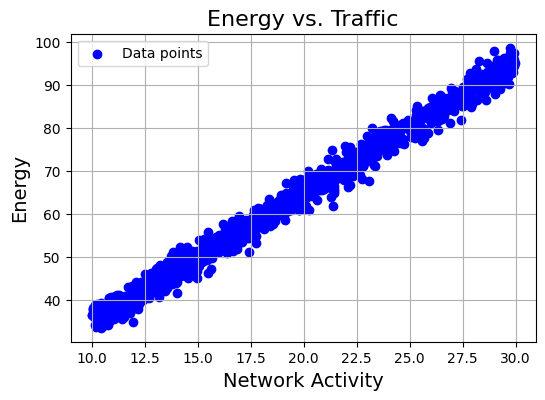

In [3]:
# Load data
data = pd.read_csv('regression.csv')

# Plot the data
plt.figure(figsize=(6, 4))
plt.scatter(data['Net_Activity'], data['Energy'], c='blue', label='Data points')
plt.grid(True)
plt.xlabel('Network Activity', fontsize=14)
plt.ylabel('Energy', fontsize=14)
plt.title('Energy vs. Traffic', fontsize=16)
plt.legend()
plt.show()

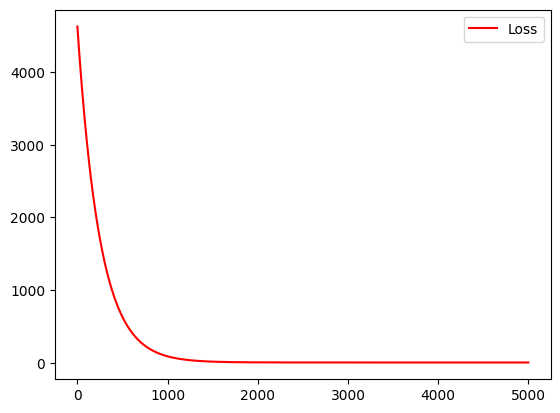

Net Activity = Net_Activity    17.2
dtype: float64 * Energy + 65.78
[np.float64(3.879330760840943), np.float64(3.8793307219408213), np.float64(3.8793306831961316), np.float64(3.8793306446062545), np.float64(3.879330606170569), np.float64(3.879330567888459), np.float64(3.879330529759313), np.float64(3.8793304917825187), np.float64(3.8793304539574667), np.float64(3.87933041628355)]
0.002956568183340984
-0.1361573004595139


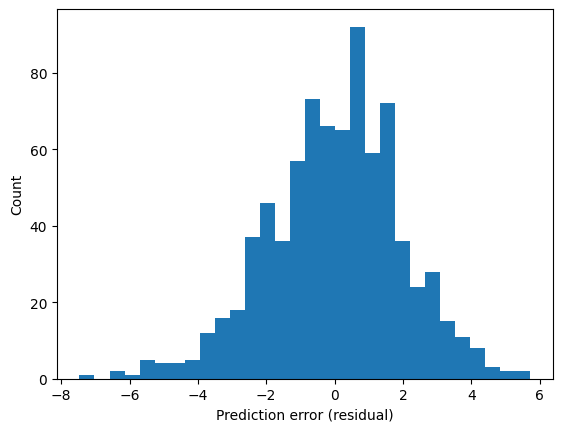

In [4]:
# ====================================
# LOSS CURVE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linear_models import LinearRegression
from sklearn.model_selection import train_test_split


data = pd.read_csv("regression.csv")
X = data[["Net_Activity"]] #2D, for å gjøre plottinga med X.shape[] enklere
y = data["Energy"]
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size= 0.2)

# Regn ut gjennomsnitt og standardavvik
X_mean = X_train.mean()
X_std = X_train.std()

# Skalering
X_train_scaled = (X_train - X_mean) / X_std
X_test_scaled = (X_test - X_mean) / X_std

lin_reg = LinearRegression(lr=0.001, n_iterations=5000)
lin_reg.fit(X_train_scaled, y_train)
epoch_list = np.arange(lin_reg.n_iterations)

plt.plot(epoch_list, lin_reg.loss_history, c = 'Red', label="Loss")
plt.legend()
plt.show()

#Yes, we have a stable loss curve, after scaling with mean and std. 

# ====================================

#FITTED CURVE AND DERIVE ENERGY CONSUMPTION FORMULA
#We use our computed values for weights and bias:
print(f'Net Activity = {lin_reg.weights.round(2)} * Energy + {lin_reg.bias.round(2)}')

#PREDICTION ERROR DISTRIBUTION
# An unbiased estimator is, from statistics an estimator with expected value equal to the value it wants to estimate. 
# For our case, we do so many simulations, that the central limit theorem gets useful, and this gives us an estimator that should have
# expected value equal to the mean. 

train_predictions = lin_reg.predict(X_train_scaled)
train_residuals = y_train - train_predictions

test_predictions = lin_reg.predict(X_test_scaled)
test_residuals = y_test - test_predictions

#Print og plott av residualene (feilleddene=)
print(lin_reg.loss_history[-10:])
print(train_residuals.mean())
print(test_residuals.mean())
plt.hist(train_residuals, bins=30)
plt.xlabel("Prediction error (residual)")
plt.ylabel("Count")
plt.show()

#Kommentar: Her måtte jeg endre iterasjoner fra 1000 til 10000, slik at feilen gikk mot 0

# SGD close to zero
# When the SGD is close to zero it means that we are close to minimum of the loss function. The model has converged, changes in the parameters
# make insignificant changes to the model. 

### ❓ Is the training loss curve stable?

### ❓ Derive the resulting energy consumption formula

### ❓ Analyze prediction error distribution. What is an unbiased estimator?

### ❓ What does it tell you when the gradient in SGD is close to zero?

## 🔋 Problem 2: Logistic regression

### Your task
1. Implement logistic regression
2. Train your model on binary classification data
3. Engineer features to improve the model's performance

### Formal requirements
1. **Implementation**:
   - Same as before, use standard libraries
   - Implement gradient descent

2. **Performance**: Achieve at least **0.88** classification accuracy on the test set

3. **Discussion**:
   - Explain poor initial performance and your improvements
   - What is the model's inductive bias. Why is it important?
   - Plot the ROC curve, what does the area under the curve measure?

In [5]:
data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']

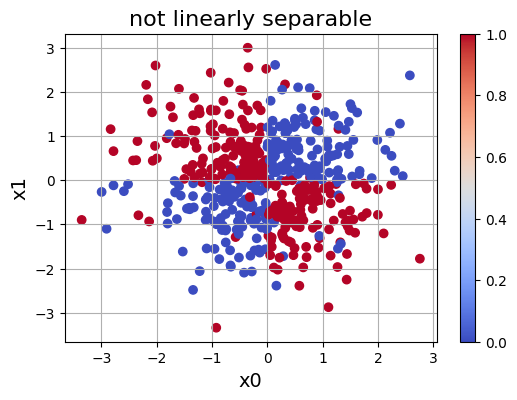

In [6]:
# visualize x0 and x1 of train on scatterplot with colors corresponding to y
plt.figure(figsize=(6, 4))
plt.scatter(train['x0'], train['x1'], c=train['y'], cmap='coolwarm')
plt.grid(True)
plt.xlabel('x0', fontsize=14)
plt.ylabel('x1', fontsize=14)
plt.title('not linearly separable', fontsize=16)
plt.colorbar()
plt.show()

### ❓ Explain poor initial performance and your improvements

### ❓ What is the model's inductive bias? Why is it important?

### ❓ What does the area under the ROC curve measure?

[np.float64(0.6931471805599453), np.float64(0.6855896021961523), np.float64(0.6784516503817363), np.float64(0.671707795285388), np.float64(0.6653329123577179)]
[np.float64(0.45814530998526154), np.float64(0.458142992475167), np.float64(0.45814068397200464), np.float64(0.45813838443800664), np.float64(0.4581360938355785)]
0.4581360938355785 0.6931471805599453
[-0.25757659 -0.02661934 -2.87861209] 0.013051180944606541
[np.float64(0.4834307992202729), np.float64(0.8557504873294347), np.float64(0.8576998050682261), np.float64(0.8615984405458089), np.float64(0.8615984405458089)]
[np.float64(0.9200779727095516), np.float64(0.9200779727095516), np.float64(0.9200779727095516), np.float64(0.9200779727095516), np.float64(0.9200779727095516)]


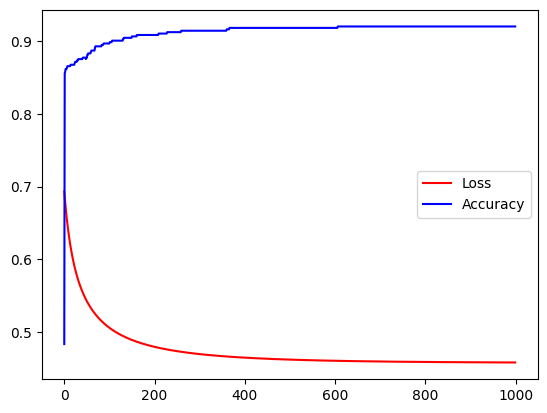

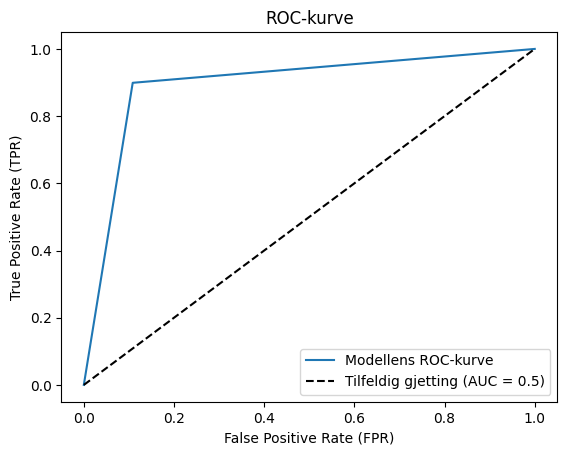

In [7]:
# ====================================
# TRAINING
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from linear_models import LogisticRegression
from sklearn.metrics import roc_curve

data = pd.read_csv('classification.csv')
train = data[data['split'] == 'train']
test = data[data['split'] == 'test']
epoch = 1000

#Initialize and train model
X_train = np.column_stack((train.x0, train.x1, train.x0 * train.x1))
X_test = np.column_stack((test.x0, test.x1, test.x0 * test.x1)) 
log_reg = LogisticRegression(0.1, epoch)
log_reg.fit(X_train, np.array(train.y))

# Make predictions
predictions = log_reg.predict_proba(X_test)

#Plot

epoch_list = np.arange(0, epoch, 1)

print(log_reg.loss_history[:5])
print(log_reg.loss_history[-5:])
print(min(log_reg.loss_history), max(log_reg.loss_history))
print(log_reg.weights, log_reg.bias)
print(log_reg.train_accuracies[:5])
print(log_reg.train_accuracies[-5:])

plt.plot(epoch_list, log_reg.loss_history, c = 'Red', label="Loss")
plt.plot(epoch_list, log_reg.train_accuracies, c= 'Blue', label="Accuracy")
plt.legend()
plt.show()



 # EXPLAIN POOR INITIAL PERFORMANCE AND YOUR IMPROVEMENTS

 # The reason for poor initial performance is being shown of the scatterplot of x0 and x1, and the headline that it is not linearly seperable,
 # and the privelige of logistic regression is that we can use a new dimension, and find contexts of the data that doesn't exists with only linear regression.

 # WHAT IS THE MODELS INDUCTIVE BIAS

# The models inductive bias is a linear context, as for the linear regression. The only difference is that we now use the sigmoid function,
# but the same thought of linearity also appears for logistic regression. 

 # PLOTTING AV ROC-KURVE
fpr, tpr, tresholds = roc_curve(test.y, predictions)

plt.plot(fpr, tpr, label='Modellens ROC-kurve')
plt.plot([0, 1], [0, 1], 'k--', label='Tilfeldig gjetting (AUC = 0.5)')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('ROC-kurve')
plt.legend()
plt.show()

 # The area under the ROC-Curve represents the probability that the model will predict a higher value for a randomly picked
 # positive datapoint than a randomly picked negative datapoint. For this case we can see from the plot that the are under the curve
 # can be computed from the sum of the integral of two linear functions eg. approximately 9x and 1/9x + 0.9, which gives the 
 # integral of 9/2*x^2 from x=0 to x=0.1, which equals 0,045. For the second linear function we get 1/18*x^2 + 0.9x from x=0.1 to
 # x=1.0. This gives 1/18 + 0.9 - (1/18*0,1^2 + 0.9*0.1) = 0.865. This gives a total area and probablity of 0,865 + 0,045 = 0,91.

 